###### 3/28/2026
## Neural Network Modeling for Climate Data


#### Variable and Parameters Names
 - Climate = the original data set (146 observations with 19 parameters)
 - months = Monthly climate data
 - J.D = Jan - Dec (Yearly temp)
 - N.D = Dec - Nov (Meteorological Year)
 - DJF = Dec, Jan, Feb
 - MAM = Mar, Apr, May
 - JJA = June, July, Aug
 - SON = Sep, Oct, Nov

In [1]:
# Libraries to for use
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transform
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit, train_test_split
#from statmodels import 
#from pmdarima.fit import summary, predict


## Cross Validation -- Rolling Origin CV with Profit Package

# Setting graph style:
plt.style.use('bmh')

device_gpu = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_cpu = torch.device('cpu')

print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total Memory: {torch.cuda.get_device_properties(0).total_memory // 1e9} GB")

GPU Available: False


#### Initial Loading and processing of data:

In [2]:
Climate = pd.read_csv("Data/Global means.csv")

## Cleaning Missing Values, by averaging over the data we have. 
labelsDJ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
labelsDJF = ['Jan', 'Feb']


Climate.at[0,"D-N"] = str(Climate.loc[0,labelsDJ].mean().round(2))
Climate.at[0,"DJF"] =  str(Climate.loc[0,labelsDJF].mean())

Climate["D-N"] = pd.to_numeric(Climate["D-N"])
Climate["DJF"] = pd.to_numeric(Climate["DJF"])

Climate.tail()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
141,2021,0.81,0.64,0.89,0.76,0.79,0.85,0.92,0.81,0.93,0.99,0.93,0.87,0.85,0.84,0.75,0.81,0.86,0.95
142,2022,0.91,0.89,1.05,0.84,0.84,0.92,0.94,0.95,0.89,0.97,0.73,0.80,0.89,0.90,0.89,0.91,0.94,0.86
143,2023,0.88,0.97,1.23,0.99,0.94,1.09,1.20,1.19,1.48,1.34,1.40,1.37,1.17,1.13,0.88,1.05,1.16,1.41
144,2024,1.25,1.44,1.39,1.31,1.15,1.20,1.20,1.29,1.24,1.33,1.30,1.27,1.28,1.29,1.36,1.28,1.23,1.29
145,2025,1.38,1.26,1.36,1.23,1.08,1.05,1.02,1.16,1.25,1.19,1.21,1.05,1.19,1.21,1.30,1.22,1.08,1.22


#### Handling the data

In [3]:
climate = pd.DataFrame(Climate[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov',"Dec"]])
climate.head()

## Indexing the time for future use. 
time_index_month = pd.date_range(start = "1880", end = "2026", freq = "MS")
time_index_month = time_index_month.drop(time_index_month[-1])

time_index_year = pd.date_range(start = "1880", end = "2025", freq = "YS")
print(time_index_month)

DatetimeIndex(['1880-01-01', '1880-02-01', '1880-03-01', '1880-04-01',
               '1880-05-01', '1880-06-01', '1880-07-01', '1880-08-01',
               '1880-09-01', '1880-10-01',
               ...
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01',
               '2025-11-01', '2025-12-01'],
              dtype='datetime64[us]', length=1752, freq='MS')


#### Setting up a simple Neural Network, to built the framework.

In [4]:
## Normalizing the data and converting to a tensor. 
months = climate
years = Climate["Year"]
averages = Climate["J-D"]

standard = (months - np.mean(months))/(np.std(months))
month = torch.tensor(standard.values, dtype=torch.float32)
y = torch.tensor(averages - np.mean(averages))/(np.std(averages))
year = torch.tensor(years)


## Creating a function to backtransform:
def backtransform(x):
    back = x*np.std(months) + np.mean(months)
    return(back)


In [18]:
## Setting a simple neural network:
class simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(12, 4), ## Amount of data in, Amount of data out???
            nn.ReLU(),
            nn.Linear(4,1)
        )

    def forward(self, x):
        return self.network(x)

model = simple()
print(model)

simple(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  )
)


In [19]:
## Running the terrible NN forward once
sample = month[:1]
est = model(sample).item()
print(f'Initial Forward Estiamte {backtransform(est):.3f}')

## Terrible estimate

Initial Forward Estiamte 0.119


In [20]:
## Choosing loss functions
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr = .01)

In [47]:
## Running the NN
for epoch in range(4):
    running_loss = 0.0

    model.train()
    for i in range(len(month) - 1):
        # Forward
        output = model(month[i:i + 1]).float()
        loss = criterion(output, y[i:i + 1]).float()

        #Backword
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Runnig Loss: {running_loss:.3f}')

C:\Users\dustin.smith\AppData\Local\anaconda3\envs\torch_env\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: Found dtype Double but expected Float

In [22]:
## Running the model:
model.eval()
with torch.no_grad():
    # Stay in PyTorch for the math
    raw_outputs = model(month)
    final_values = backtransform(raw_outputs) 

# Now move to NumPy or List for printing/plotting
final_list = final_values.flatten().tolist()
for i in range(len(final_list) - 125):
    print(f"Prediction: {final_list[i]:.2f}")

Prediction: -0.16
Prediction: -0.08
Prediction: -0.11
Prediction: -0.16
Prediction: -0.26
Prediction: -0.30
Prediction: -0.29
Prediction: -0.33
Prediction: -0.16
Prediction: -0.10
Prediction: -0.33
Prediction: -0.21
Prediction: -0.25
Prediction: -0.28
Prediction: -0.28
Prediction: -0.21
Prediction: -0.11
Prediction: -0.11
Prediction: -0.27
Prediction: -0.16
Prediction: -0.08


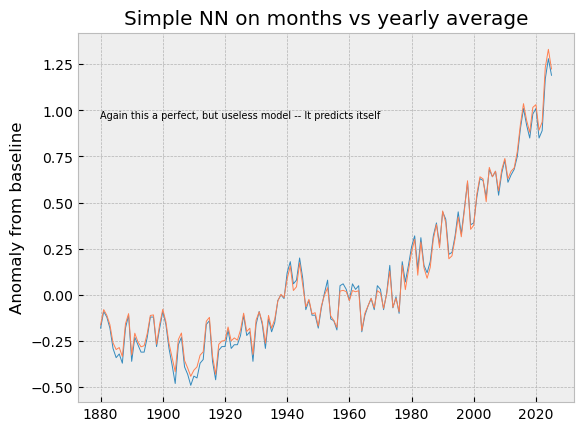

In [23]:
## plotting graph for shits and giggles
plot_df = pd.DataFrame({
    "time": time_index_year,
    "prediction": final_list, 
    "original": Climate["J-D"]})

plt.plot(plot_df.time, plot_df.original, color = "#348ABD", linewidth = .7)
plt.plot(plot_df.time, plot_df.prediction, color = "coral", linewidth = .7)
plt.title("Simple NN on months vs yearly average")
plt.ylabel("Anomaly from baseline")
plt.text(1., 1.0, "Again this a perfect, but useless model -- It predicts itself",
        horizontalalignment='right',
        verticalalignment='top', 
        fontsize = 7)
plt.show()

#### Attempting a 'Sliding Window' indexing for 1 year forcasting using LTSM (tensor slicing?)

In [24]:
## Attempting to create the Sliding Window:
# Creating a flattened data frame for analysis. 
flat_df = pd.DataFrame({
    "time": time_index_month, 
    "original": standard.values.flatten()}) # From standardizing above. 

## To check if the data is actually standardized. 
# print(flat_df.original.mean(), flat_df.original.std())

# The window function will spit out lagged and lead data based on outside indexing. 
start = 0
length = 24
lead = 12 # Just for something to work with 
def window(timeseries, start, length, lead):
    #hanlde the start and index through the lenght 
    # Notes: using loc changes the indexing some, 
    # where lagged with be +1 for the length, while lead will match lead length. 
    lagged = timeseries.iloc[start: start + length]
    #hanlde the future y output for loss testing
    future = start + length
    leads = timeseries.iloc[future: future + lead] 
    #increase indexing outside of the definition to avoid memory problems. Should forget test after?
    #make it produce a tuple?? test set, train set
    return torch.tensor(lagged.values, dtype = torch.float32), torch.tensor(leads.values, dtype = torch.float32) # Set to 16 if it takes too long.
    #the length will need to match the hidden layer input. 

    
    #lets keep the standardizing out of the fucntion for now. 

In [30]:
## Checking my function. 
lagged, lead = window(flat_df.original, start = 0, length = 3, lead = 2)
print(f'Lagged:   length {len(lagged)}, Values: {lagged}')
print(f'Lead:     length {len(lead)}, Values: {lead}')

Lagged:   length 3, Values: tensor([-0.6538, -0.7984, -0.4370])
Lead:     length 2, Values: tensor([-0.6056, -0.4611])


In [31]:
standard.head(2) ## For checking the above values to see that they are indexing correclty:

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,-0.653821,-0.798354,-0.437022,-0.605643,-0.461111,-0.726087,-0.653821,-0.461111,-0.557466,-0.774265,-0.750176,-0.629732
1,-0.677910,-0.557466,-0.123868,-0.099779,-0.075690,-0.653821,-0.196134,-0.292489,-0.581555,-0.726087,-0.653821,-0.364756


In [50]:
## Creating the NN framework
class SlidingWindow(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(24,16),
            nn.LeakyReLU(),
            nn.Linear(16,12),
            nn.LeakyReLU(),
            nn.Linear(12,12)
         )

        # The forward will need more editing for when using LTSM
    def forward(self, x):
        return self.network(x)


tsmodel = SlidingWindow()
print(tsmodel)

SlidingWindow(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=16, out_features=12, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=12, out_features=12, bias=True)
  )
)


In [51]:
# Notes: You need to force the NN to stop before forward indexing fails. The last so many months must be purly test data. 
# Notes: you may encounter an error when attempting RNN or LTSM, suggested using .unsqueeze(-1) to fix it. 

## Choose loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(tsmodel.parameters(), lr=0.01)

## Begin for loop
for epoch in range(40):
    running_loss = 0.0
    pred = []

    # need to create an outside value for past lag and lead. 
    start = 0
    length = 24
    lead = 12 
    
    ## Iterate you sliding window
    tsmodel.train()
    for i in range(0,len(flat_df.original) - lead - length, lead): #Attempting in loop through the time data while, but stop before overindexing. 
        lags, leads = window(flat_df.original, i, length, lead)
        lags_dim = lags.view(1, -1)
        leads_dim = leads.view(1, -1)
        
        ## Forward pass
        outputs = tsmodel(lags_dim)
        loss = criterion(outputs, leads_dim)

        ## Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        ## record loss increase lead indexing
        running_loss += loss.item()
        # pred[i] = outputs.detach().cpu().numpy().flatten()
        
    print(f'Runnig Loss: {running_loss:.3f}')
    
    ## Record future values for plotting future bootstrap confidence intervals. 

Runnig Loss: 30.513
Runnig Loss: 25.036
Runnig Loss: 22.423
Runnig Loss: 25.213
Runnig Loss: 22.008
Runnig Loss: 19.791
Runnig Loss: 19.554
Runnig Loss: 18.764
Runnig Loss: 18.991
Runnig Loss: 19.560
Runnig Loss: 18.531
Runnig Loss: 18.195
Runnig Loss: 18.706
Runnig Loss: 18.073
Runnig Loss: 17.311
Runnig Loss: 19.566
Runnig Loss: 19.315
Runnig Loss: 18.428
Runnig Loss: 18.930
Runnig Loss: 17.970
Runnig Loss: 17.377
Runnig Loss: 17.529
Runnig Loss: 17.422
Runnig Loss: 17.049
Runnig Loss: 17.462
Runnig Loss: 17.400
Runnig Loss: 17.593
Runnig Loss: 16.129
Runnig Loss: 17.207
Runnig Loss: 16.539
Runnig Loss: 17.072
Runnig Loss: 18.403
Runnig Loss: 19.775
Runnig Loss: 17.493
Runnig Loss: 16.555
Runnig Loss: 17.008
Runnig Loss: 17.599
Runnig Loss: 16.469
Runnig Loss: 16.329
Runnig Loss: 16.049


In [52]:
## Average loss for each lead tested. 
num_windows = len(range(0, len(flat_df.original) - lead - length, lead))
print(f"Actual windows: {num_windows}")
print(f"True Avg Loss: {running_loss / num_windows}")

Actual windows: 143
True Avg Loss: 0.11223033978440962


In [53]:
## finding predictions
tsmodel.eval()
pred = []

with torch.no_grad():
    for i in range(0,len(flat_df.original) - length, lead): # should run each of the future of 6 months at a time. 
                                                                # Adding 6 allows for future data predictions. 
        lags, __ = window(flat_df.original, i, length, lead)
        output = tsmodel(lags)
        pred.append(output)

# Condensing the predictions into one array and backtransforming it
slid_prediction = (np.concatenate(pred))

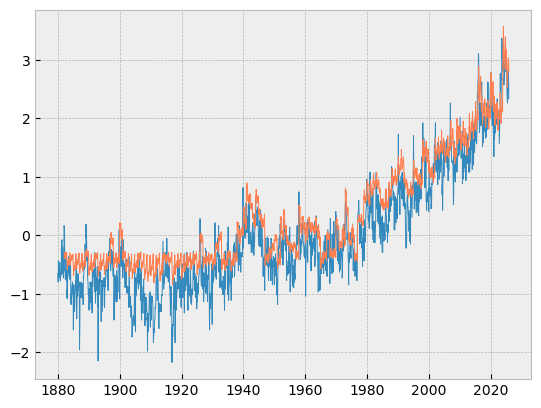

In [54]:
## plotting the data
## Neither data has been back transformed
plt.plot(flat_df.time, flat_df.original, color = "#348ABD", linewidth = .7)
plt.plot(flat_df.time.loc[24:1752], slid_prediction, color = "coral", linewidth = .7) 
plt.show()

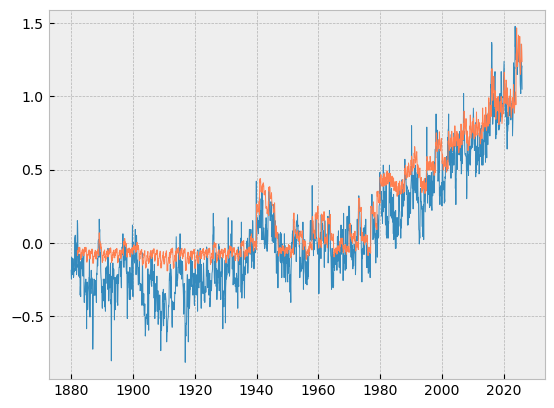

In [37]:
## With backtransforming
backor = backtransform(flat_df.original)
backpr = backtransform(slid_prediction)
plt.plot(flat_df.time, backor, color = "#348ABD", linewidth = .7)
plt.plot(flat_df.time.loc[24:1752], backpr, color = "coral", linewidth = .7) 
plt.show()

In [38]:
## calculating means squared error:
mse = np.mean((backor.loc[24:1752] - backpr)**2)
mae = np.mean(abs(backor.loc[24:1752] - backpr))
print(f'Mean Squared Error: {mse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')

Mean Squared Error: 0.0373
Mean Absolute Error: 0.1555
